In [4]:
import ipdb
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pylab as pylab
import cartopy
import cartopy.crs as ccrs
from utils import constants as cnst
from eod import msg
from utils import u_grid, u_interpolate as u_int, u_darrays as uda, u_arrays as ua
import datetime
import matplotlib.colors as mcolors
from cartopy.io.shapereader import Reader
from cartopy.feature import ShapelyFeature

pylab.rcParams['figure.figsize'] = (50., 50.)
%matplotlib inline

In [3]:
cd ..

/home/ck/pythonWorkspace/proj_CEH


In [14]:
file = '/media/ck/Elements/Africa/WestAfrica/GRIDSAT/www.ncei.noaa.gov/data/geostationary-ir-channel-brightness-temperature-gridsat-b1/access/2008/*.nc' 
#file = '/home/ck/DIR/mymachine/GRIDSAT/MCS18/gridsat_WA_-40_1000km2_15-21UTC*.nc'

In [19]:
dat = xr.open_mfdataset(file)

In [58]:
metsat = dat['irwin_cdr'].where((dat['time.month']>=5) & (dat['time.month']<=10) & (dat['irwin_cdr'].values < 233)).sel(lon=slice(-18,20), lat=slice(5,30)).load()

MemoryError: Unable to allocate 14.3 GiB for an array with shape (2928, 1172, 1115) and data type float32

In [21]:
metsat = metsat.diff('time')

In [56]:
metsat.values

array([[[ 46.950012  ,  38.08      ,  26.880005  , ...,  15.339996  ,
           8.630005  ,   6.3099976 ],
        [ 35.350006  ,  28.029999  ,  20.440002  , ...,   7.139984  ,
           7.080017  ,   9.430008  ],
        [ 20.500015  ,  18.12999   ,  13.520004  , ...,   1.8899841 ,
          -3.0400085 ,  -3.730011  ],
        ...,
        [ -0.29000854,  -0.80999756,  -0.80999756, ...,  -1.4099731 ,
          -1.4099731 ,  -1.9199829 ],
        [ -0.29000854,  -0.80999756,  -0.80999756, ...,  -1.9199829 ,
          -1.9199829 ,  -2.4700012 ],
        [ -7.6500244 ,  -2.380005  ,  -5.        , ...,  -0.80999756,
          -1.9199829 ,  -2.4700012 ]],

       [[-46.10002   ,  11.710022  ,  30.01001   , ..., -10.559998  ,
          -9.670013  , -12.090012  ],
        [-10.160004  ,  27.529999  ,  48.119995  , ..., -11.37999   ,
         -13.740021  , -10.4700165 ],
        [ 25.22998   ,  41.11      ,  31.660004  , ..., -11.37999   ,
          -8.959991  ,  -8.179993  ],
        ...,


In [23]:
metsat = metsat.where((metsat['time.month']>=6) & (metsat['time.month']<=9), drop=True)

In [36]:
ts = metsat['irwin_cdr'].mean(['lat', 'lon']).resample(time='1D').mean()

In [37]:
len(ts)

122

In [43]:
def low_pass_weights(window, cutoff):
    """Calculate weights for a low pass Lanczos filter.

    Args:

    window: int
        The length of the filter window.

    cutoff: float
        The cutoff frequency in inverse time steps.

    """
    order = ((window - 1) // 2 ) + 1
    nwts = 2 * order + 1
    w = np.zeros([nwts])
    n = nwts // 2
    w[n] = 2 * cutoff
    k = np.arange(1., n)
    sigma = np.sin(np.pi * k / n) * n / (np.pi * k)
    firstfactor = np.sin(2. * np.pi * cutoff * k) / (np.pi * k)
    w[n-1:0:-1] = firstfactor * sigma
    w[n+1:-1] = firstfactor * sigma
    return w[1:-1]

In [48]:
from oceans.filters import fft_lowpass
import matplotlib.pyplot as plt
t = np.arange(len(ts))  # Time in hours.

filtered = fft_lowpass(t, low=1/60, high=1/20)

In [49]:
# construct 2-year (24-month) and 7-year (84-month) low pass filters
# for the SOI data which is monthly
window=len(ts)
wgts24 = low_pass_weights(window, 1. / 20.)  #
wgts84 = low_pass_weights(window, 1. / 60.)

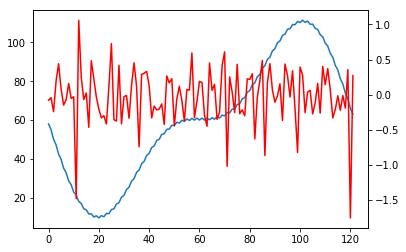

In [53]:
f = plt.figure()
ax = f.add_subplot(111)
ax.plot(filtered)
ax1 = ax.twinx()
ax1.plot(ts.values, color='r')

In [18]:
metsat['ymonth'] = ('time', [str(y)+'-'+str(m) for (y,m) in zip(mf['time.year'].values,mf['time.month'].values)])
grouped='ymonth'

#valid_days = mf.groupby(grouped).count(dm='time') # number of valid days per month

minus =  mf.groupby(grouped).mean(dim='time')
# arr = minus.values
#
# arr[valid_days.values<10] = np.nan
# minus.values = arr

dso = mf.groupby(grouped) - minus
dso = dso.drop('ymonth')

<xarray.Dataset>
Dimensions:    (lat: 357, lon: 543, time: 976)
Coordinates:
  * lon        (lon) float32 -17.949997 -17.880005 ... 19.919998 19.990005
  * lat        (lat) float32 5.040001 5.1100006 5.1800003 ... 29.82 29.89 29.96
  * time       (time) datetime64[ns] 2008-06-01 ... 2008-09-30T21:00:00
Data variables:
    irwin_cdr  (time, lat, lon) float32 279.33002 259.62 ... 292.57 293.08
Attributes:
    CDI:                        Climate Data Interface version 1.6.9 (http://...
    history:                    Sat Mar 31 10:57:51 2018: cdo sellonlatbox,-2...
    source:                     ISCCP.B1U.a.GOE-12.2007.12.31.2345.MSC.gz,ISC...
    institution:                DOC/NOAA/NESDIS/NCDC > National Climatic Data...
    Conventions:                CF-1.6
    title:                      GridSat-B1 - Gridded Satellite (GridSat) ISCC...
    summary:                    Geostationary data are remapped to equal angl...
    Metadata_Conventions:       CF-1.6, Unidata Dataset Discovery v1.0, NOAA ...
    references:                 http://dx.doi.org/10.1175/2011BAMS3039.1  htt...
    id:                         GRIDSAT-B1.2008.01.01.00.v02r01.nc
    naming_authority:           gov.noaa.ncdc
    license:                    No constraints on data access or use.
    processing_level:           NOAA Level 3
    standard_name_vocabulary:   CF Standard Name Table (v23, 23 March 2013)
    cdr_program:                NOAA Climate Data Record Program for satellit...
    cdr_variable:               irwin_cdr
    software_version_id:        $Id: b1u_2_grisat.pro 45405 2014-04-04 19:22:...
    metadata_link:              gov.noaa.ncdc:C00829
    product_version:            v02r01
    platform:                   GOES-12 > Geostationary Operational Environme...
    sensor:                     GOES I-M IMAGER, MVIRI > Meteosat Visible and...
    spatial_resolution:         Approx. 8 km at Equator
    keywords:                   EARTH SCIENCE > Atmosphere > Clouds > Cloud T...
    keywords_vocabulary:        GCMD Science Keywords, http://gcmd.gsfc.nasa....
    svn_info_b1u2grisat:        $Id: b1u_2_grisat.pro 45405 2014-04-04 19:22:...
    version_info:               v02r01
    date_created:               2014-04-12T14:24:13
    date_created_format2:       Sat Apr 12 18:24:13 2014 UTC
    date_created_format1:       1397327053 seconds since 1 Jan 1970 00:00 UTC
    creator_name:               Ken Knapp, NOAA/NESDIS/NCDC/RSAD
    creator_url:                http://www.ncdc.noaa.gov/ http://www.ncdc.noa...
    creator_email:              NCDC.Satorder@noaa.gov Ken.Knapp@noaa.gov
    date_modified:              2014-04-12T14:24:13
    Projection:                 Mercator
    cdm_data_type:              Grid
    geospatial_lat_min:         -70.0
    geospatial_lat_max:         69.93001
    geospatial_lon_min:         -180.0
    geospatial_lon_max:         179.94
    geospatial_lat_units:       degrees_north
    geospatial_lat_resolution:  0.07
    geospatial_lon_units:       degrees_east
    geospatial_lon_resolution:  0.07
    base_date:                  [2.008e+03 1.000e+00 1.000e+00]
    time_coverage_start:        2008-01-01T00:00:00
    time_coverage_end:          2008-01-01T00:30:00
    _satid:                     _satid attributes are comma delimited arrays ...
    Satellite_Name_satid:       GOES-12,Meteosat-7,MTSAT-1R,FY-2C,GOES-11
    B1U_File_satid:             ISCCP.B1U.a.GOE-12.2007.12.31.2345.MSC.gz,ISC...
    IRWIN_calibration_file:     b1u.calibration.correction.IRWIN.v17
    IRWVP_calibration_version:  v01
    Corrections:                IRWIN has VZA correction, All channels have p...
    CDO:                        Climate Data Operators version 1.6.9 (http://...

In [ ]:
metsat

In [33]:
def draw_map(ax, t, lat, lon, **kwargs):
    
    fname = '/home/ck/DIR/cornkle/data/HUARAZ/shapes/riosan_sel_one.shp'
    
    shape_feature = ShapelyFeature(Reader(fname).geometries(),
                                   ccrs.PlateCarree(), facecolor='none' , edgecolor='black')


    plt.contourf(lon, lat, t, transform=ccrs.PlateCarree(), **kwargs)
    ax.coastlines()
    #ipdb.set_trace()
    
#     ax.add_geometries(Reader(fname).geometries(),
#                   ccrs.PlateCarree(),
#                   facecolor='white', hatch='xxxx')
    # Gridlines
    xl = ax.gridlines(draw_labels=True);
    xl.xlabels_top = False
    xl.ylabels_right = False
    # Countries
    #ax.add_feature(cartopy.feature.BORDERS, linestyle='--');
    ax.add_feature(shape_feature, linestyle='--');
    plt.colorbar()

In [34]:
# sample the colormaps that you want to use. Use 128 from each so we get 256
# colors in total
colors1 = plt.cm.terrain(np.linspace(0., 1, 150))
colors2 = plt.cm.Reds(np.linspace(0, 1, 100))

# combine them and build a new colormap
colors = np.vstack((colors2, colors1))
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

In [35]:
print(19,22,1,4,7,10,13,16, 'LT')
print(0,3,6,9,12,15,18,21, 'UTC')

19 22 1 4 7 10 13 16 LT
0 3 6 9 12 15 18 21 UTC


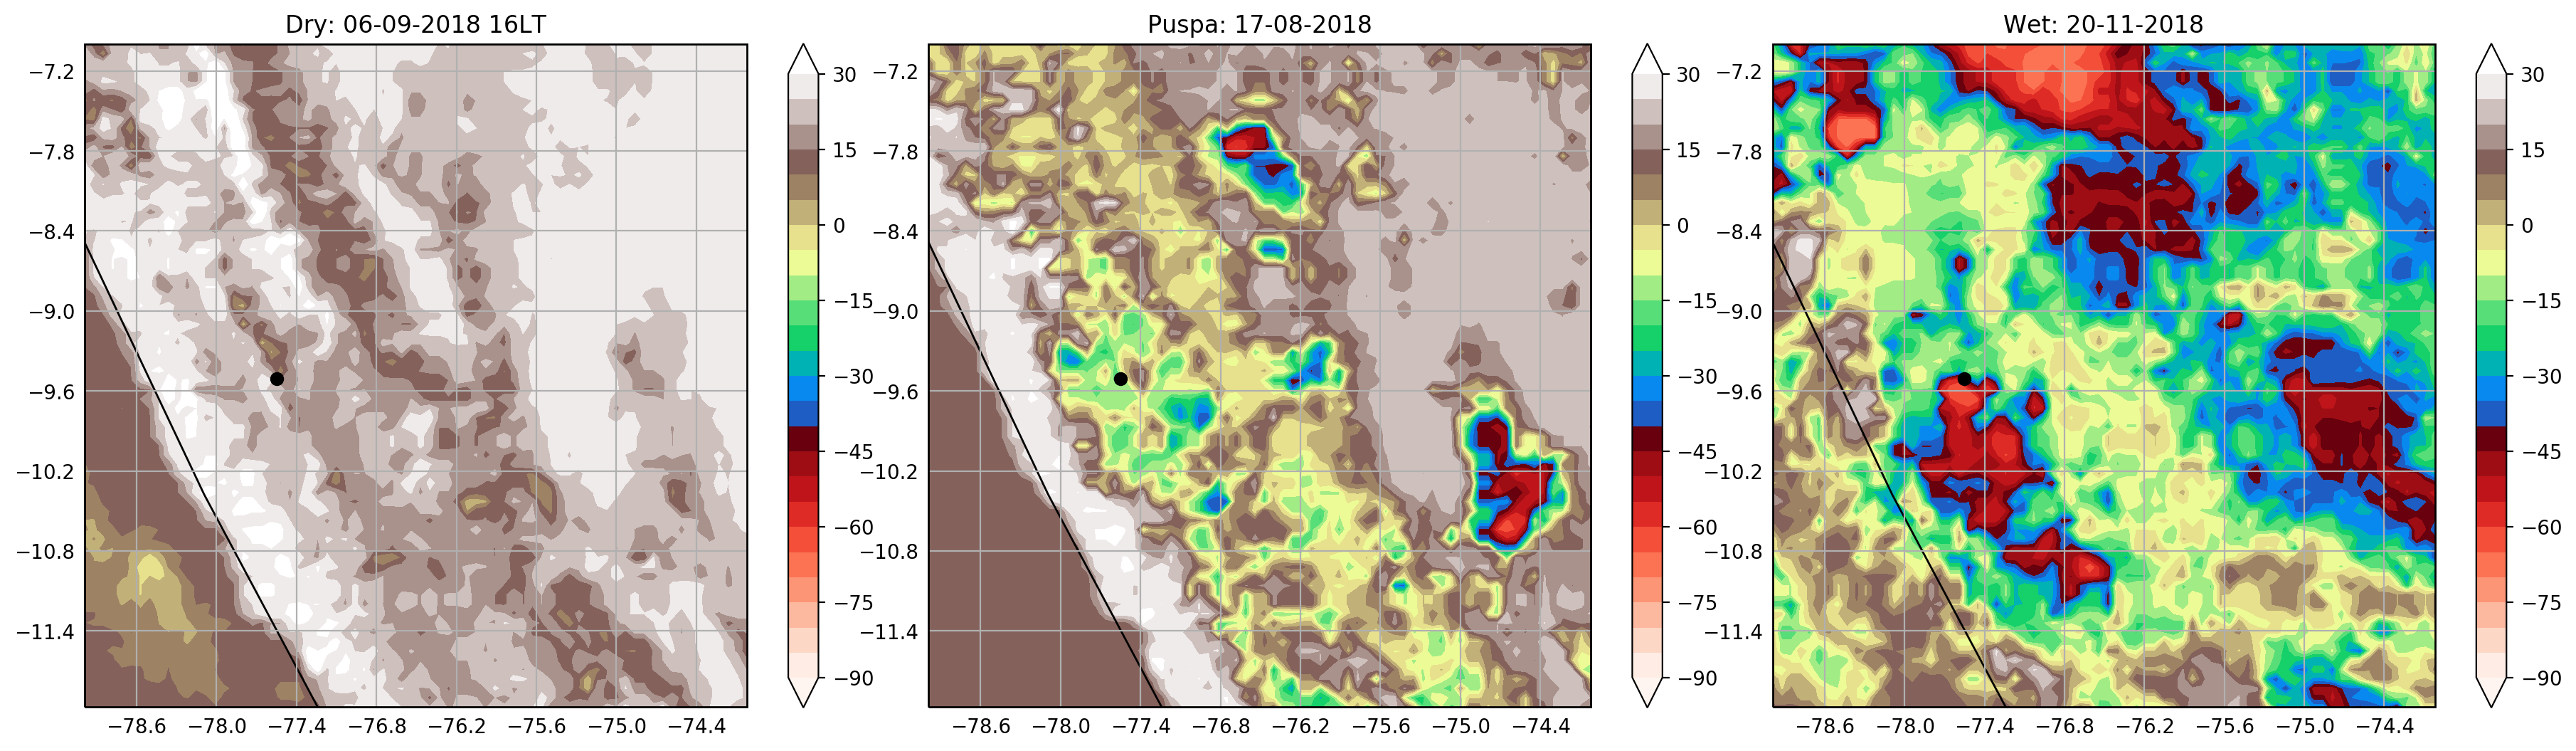

In [36]:
h = 21

f=plt.figure(figsize=(18,5), dpi=200)
ax = f.add_subplot(131, projection=ccrs.PlateCarree())
draw_map(ax,dry['irwin_cdr'].sel(time=dry['time.hour']==h).squeeze()-273.15, dry.lat, dry.lon, cmap=mymap, extend='both', levels=np.arange(-90,31,5))
plt.plot(-77.55,-9.51, 'ko')
plt.title('Dry: 06-09-2018 '+str(h-5)+'LT')

ax = f.add_subplot(132, projection=ccrs.PlateCarree())
draw_map(ax,puspa['irwin_cdr'].sel(time=puspa['time.hour']==h).squeeze()-273.15, dry.lat, dry.lon, cmap=mymap, extend='both', levels=np.arange(-90,31,5))
plt.plot(-77.55,-9.51, 'ko')
plt.title('Puspa: 17-08-2018')

ax = f.add_subplot(133, projection=ccrs.PlateCarree())
draw_map(ax,wet['irwin_cdr'].sel(time=wet['time.hour']==h).squeeze()-273.15, dry.lat, dry.lon, cmap=mymap, extend='both', levels=np.arange(-90,31,5))
plt.plot(-77.55,-9.51, 'ko')
plt.title('Wet: 20-11-2018')
plt.tight_layout()
plt.show()
#plt.savefig('/home/ck/DIR/cornkle/figs/HUARAZ/conny_examples/gridsat_example.png')

In [166]:
file = '/media/ck/Elements/SouthAmerica/GRIDSAT/3hourly/www.ncei.noaa.gov/data/geostationary-ir-channel-brightness-temperature-gridsat-b1/access/2003/*.nc' 
dat = xr.open_mfdataset(file)

/home/ck/miniconda3/lib/python3.7/site-packages/ipykernel_launcher.py:2: FutureWarning: In xarray version 0.15 the default behaviour of `open_mfdataset`
will change. To retain the existing behavior, pass
combine='nested'. To use future default behavior, pass
combine='by_coords'. See
http://xarray.pydata.org/en/stable/combining.html#combining-multi

  
/home/ck/miniconda3/lib/python3.7/site-packages/xarray/backends/api.py:933: FutureWarning: The datasets supplied have global dimension coordinates. You may want
to use the new `combine_by_coords` function (or the
`combine='by_coords'` option to `open_mfdataset`) to order the datasets
before concatenation. Alternatively, to continue concatenating based
on the order the datasets are supplied in future, please use the new
`combine_nested` function (or the `combine='nested'` option to
open_mfdataset).
  from_openmfds=True,


In [167]:
puspa = dat.sel(time='2003-03-04', lon=slice(-79,-70), lat=slice(-15,-5)).load() #12
dry = dat.sel(time='2003-01-20', lon=slice(-79,-70), lat=slice(-15,-5)).load() #06
wet = dat.sel(time='2003-01-22', lon=slice(-79,-70), lat=slice(-15,-5)).load() #20/01/2015

In [40]:
print(19,22,1,4,7,10,13,16, 'LT')
print(0,3,6,9,12,15,18,21, 'UTC')

19 22 1 4 7 10 13 16 LT
0 3 6 9 12 15 18 21 UTC


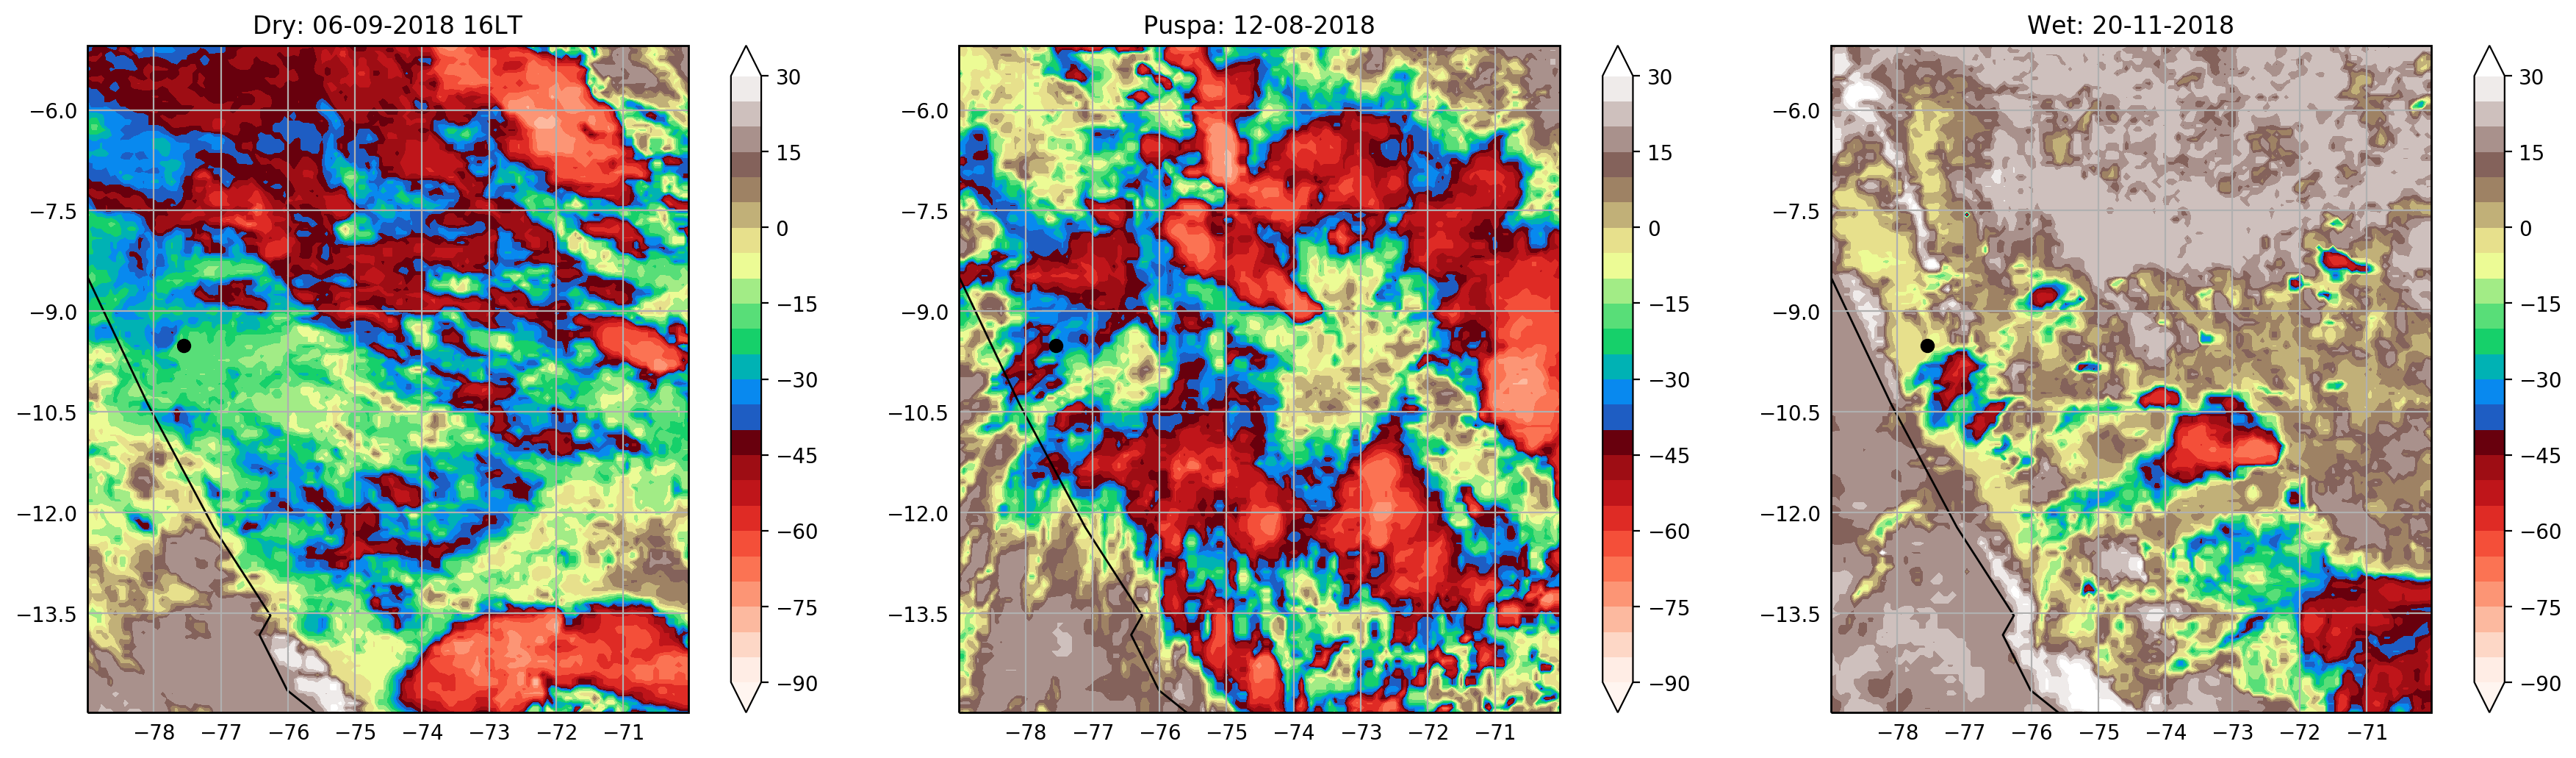

In [168]:
h = 21

f=plt.figure(figsize=(18,5), dpi=200)
ax = f.add_subplot(131, projection=ccrs.PlateCarree())
draw_map(ax,dry['irwin_cdr'].sel(time=dry['time.hour']==h).squeeze()-273.15, dry.lat, dry.lon, cmap=mymap, extend='both', levels=np.arange(-90,31,5))
plt.plot(-77.55,-9.51, 'ko')
plt.title('Dry: 06-09-2018 '+str(h-5)+'LT')

ax = f.add_subplot(132, projection=ccrs.PlateCarree())
draw_map(ax,puspa['irwin_cdr'].sel(time=puspa['time.hour']==h).squeeze()-273.15, dry.lat, dry.lon, cmap=mymap, extend='both', levels=np.arange(-90,31,5))
plt.plot(-77.55,-9.51, 'ko')
plt.title('Puspa: 12-08-2018')

ax = f.add_subplot(133, projection=ccrs.PlateCarree())
draw_map(ax,wet['irwin_cdr'].sel(time=wet['time.hour']==h).squeeze()-273.15, dry.lat, dry.lon, cmap=mymap, extend='both', levels=np.arange(-90,31,5))
plt.plot(-77.55,-9.51, 'ko')
plt.title('Wet: 20-11-2018')
plt.tight_layout()

In [78]:
topo = xr.open_dataarray(cnst.TOPO_1MIN)
topo =  topo.sel(lon=slice(-79,-65), lat=slice(-17,-3))

In [97]:
maxis = np.argmax(topo, axis=1)

In [99]:
maxis.shape

(840,)

In [100]:
topo.shape

(840, 840)

In [101]:
line = np.zeros_like(topo)
line[np.arange(topo.shape[0]),maxis] = 1

In [102]:
puspa = dat.sel(time='2015-03-02', lon=slice(-79,-65), lat=slice(-17,-3)).load() #12
dry = dat.sel(time='2015-03-04', lon=slice(-79,-65), lat=slice(-17,-3)).load() #06
wet = dat.sel(time='2015-03-05', lon=slice(-79,-65), lat=slice(-17,-3)).load() #20/01/2015

In [103]:
data = wet['irwin_cdr'].sel(time=wet['time.hour']==h).squeeze()-273.15
labels, goodinds = ua.blob_define(data.values, -40, minmax_area=[83, 25000],
                                          max_area=None)  # 7.7x7.7km = 64km2 per pix in gridsat?
data.values[labels == 0] = 0
data.values[data.values < -110] = 0

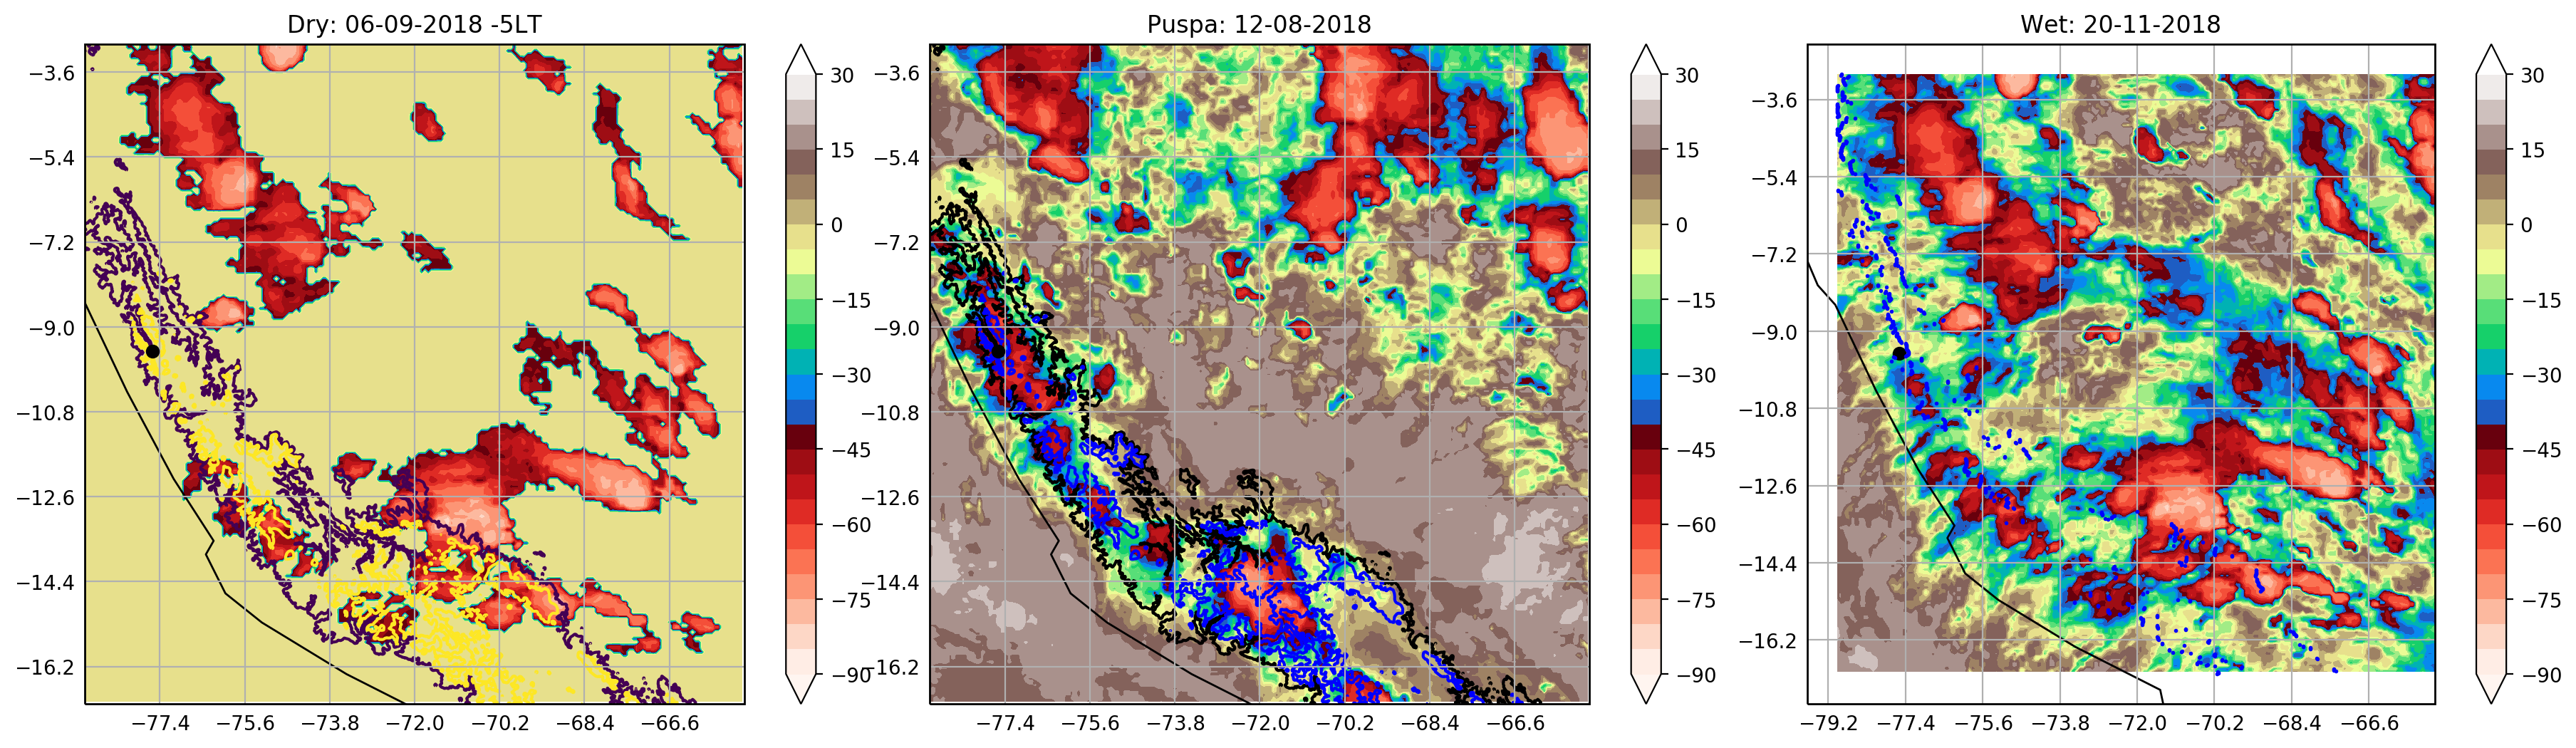

In [110]:
h = 0

f=plt.figure(figsize=(18,5), dpi=200)
ax = f.add_subplot(131, projection=ccrs.PlateCarree())
draw_map(ax,data, dry.lat, dry.lon, cmap=mymap, extend='both', levels=np.arange(-90,31,5))
plt.plot(-77.55,-9.51, 'ko')
ax.contour(topo.lon, topo.lat,topo.values, levels=[3000,4500])
plt.title('Dry: 06-09-2018 '+str(h-5)+'LT')

ax = f.add_subplot(132, projection=ccrs.PlateCarree())
draw_map(ax,puspa['irwin_cdr'].sel(time=puspa['time.hour']==h).squeeze()-273.15, dry.lat, dry.lon, cmap=mymap, extend='both', levels=np.arange(-90,31,5))
plt.plot(-77.55,-9.51, 'ko')
ax.contour(topo.lon, topo.lat,topo.values, levels=[3000,4500], colors=['black', 'blue'])
plt.title('Puspa: 12-08-2018')

ax = f.add_subplot(133, projection=ccrs.PlateCarree())
draw_map(ax,wet['irwin_cdr'].sel(time=wet['time.hour']==h).squeeze()-273.15, dry.lat, dry.lon, cmap=mymap, extend='both', levels=np.arange(-90,31,5))
plt.plot(-77.55,-9.51, 'ko')
isline = np.where(line)
ax.plot(topo.lon[isline[1]], topo.lat[isline[0]], 'bo', markersize=1)
plt.title('Wet: 20-11-2018')
plt.tight_layout()

In [165]:
file = '/media/ck/Elements/SouthAmerica/GRIDSAT/3hourly/www.ncei.noaa.gov/data/geostationary-ir-channel-brightness-temperature-gridsat-b1/access/2003/*.nc' 
dat = xr.open_mfdataset(file)

/home/ck/miniconda3/lib/python3.7/site-packages/ipykernel_launcher.py:2: FutureWarning: In xarray version 0.15 the default behaviour of `open_mfdataset`
will change. To retain the existing behavior, pass
combine='nested'. To use future default behavior, pass
combine='by_coords'. See
http://xarray.pydata.org/en/stable/combining.html#combining-multi

  
/home/ck/miniconda3/lib/python3.7/site-packages/xarray/backends/api.py:933: FutureWarning: The datasets supplied have global dimension coordinates. You may want
to use the new `combine_by_coords` function (or the
`combine='by_coords'` option to `open_mfdataset`) to order the datasets
before concatenation. Alternatively, to continue concatenating based
on the order the datasets are supplied in future, please use the new
`combine_nested` function (or the `combine='nested'` option to
open_mfdataset).
  from_openmfds=True,


In [162]:
box = [-79,-65,-17,-3]# [-79,-76,-10.8,-8.5]
topo = xr.open_dataarray(cnst.TOPO_1MIN)
topo =  topo.sel(lon=slice(box[0],box[1]), lat=slice(box[2],box[3]))
puspa = dat.sel(time='2003-03-04', lon=slice(box[0],box[1]), lat=slice(box[2],box[3])).load() #12
dry = dat.sel(time='2003-02-02', lon=slice(box[0],box[1]), lat=slice(box[2],box[3])).load() #06
wet = dat.sel(time='2003-02-03', lon=slice(box[0],box[1]), lat=slice(box[2],box[3])).load() #20/01/2015

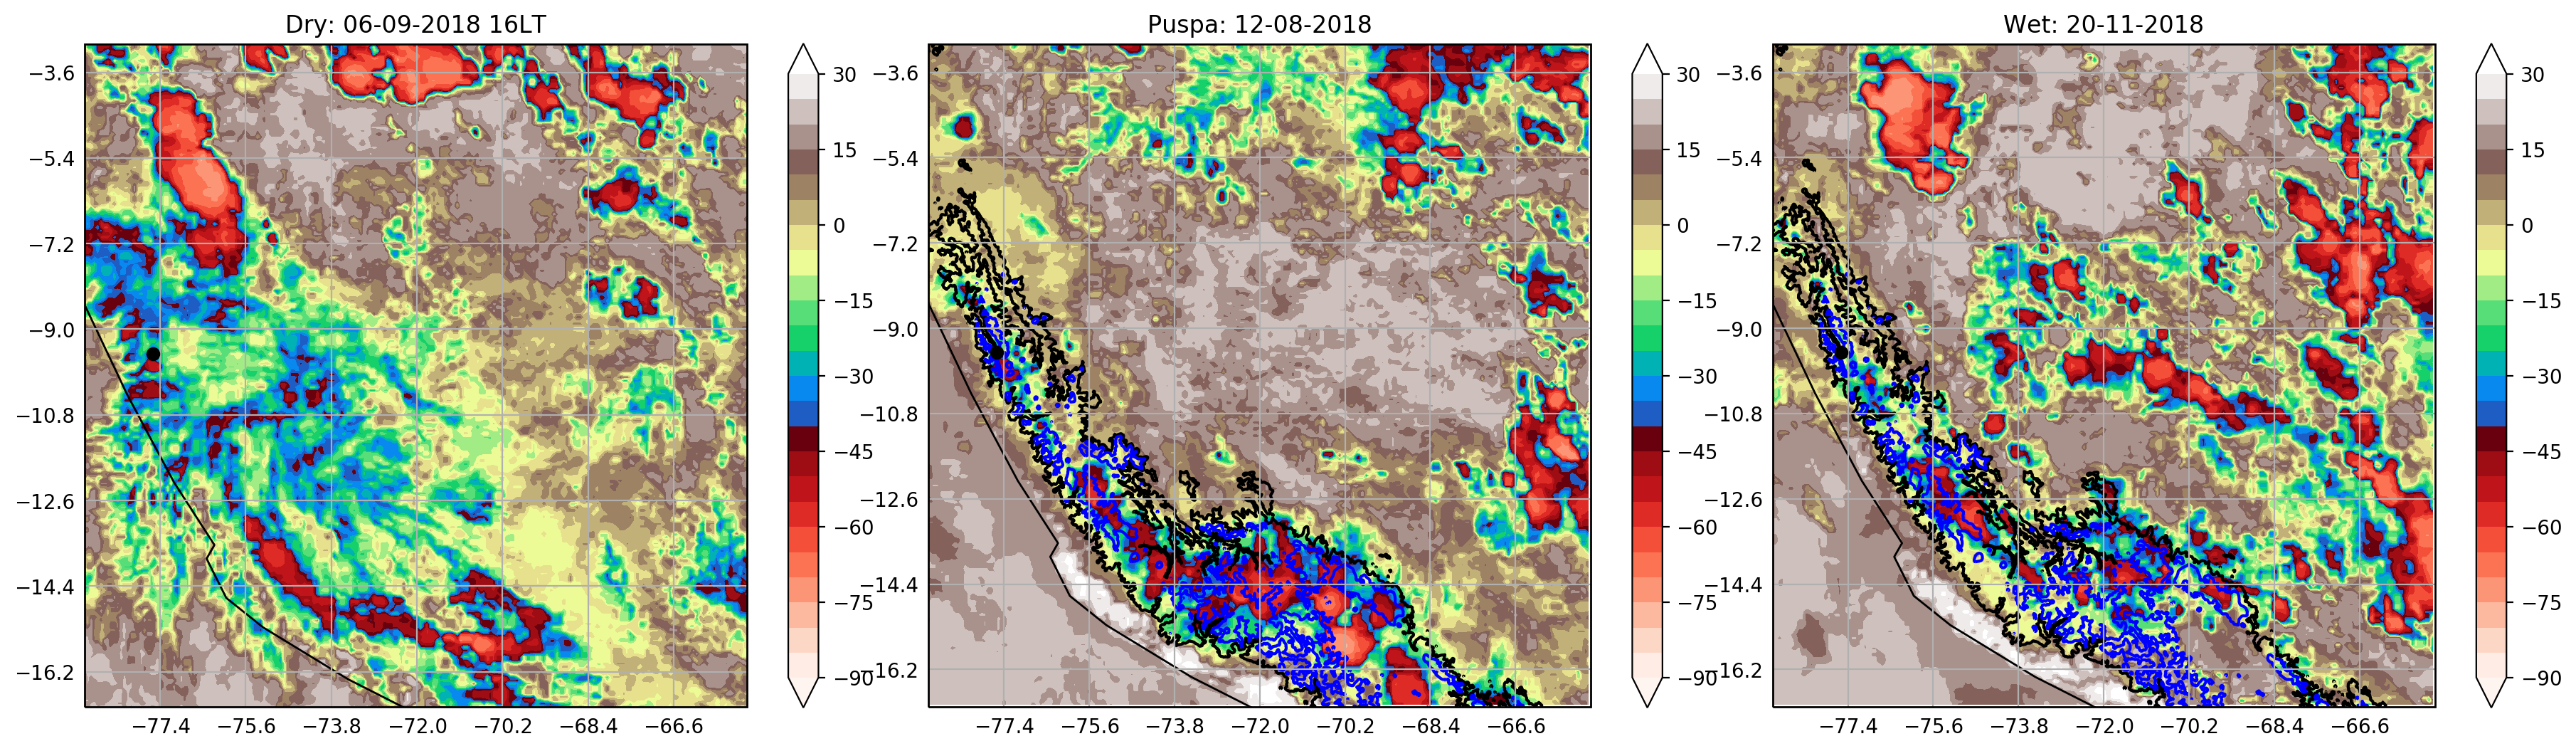

In [164]:
h = 21

f=plt.figure(figsize=(18,5), dpi=200)
ax = f.add_subplot(131, projection=ccrs.PlateCarree())
draw_map(ax,puspa['irwin_cdr'].sel(time=puspa['time.hour']==h).squeeze()-273.15, dry.lat, dry.lon, cmap=mymap, extend='both', levels=np.arange(-90,31,5))
plt.plot(-77.55,-9.51, 'ko')
#ax.contour(topo.lon, topo.lat,topo.values, levels=[3000,4500])
plt.title('Dry: 06-09-2018 '+str(h-5)+'LT')

ax = f.add_subplot(132, projection=ccrs.PlateCarree())
draw_map(ax,dry['irwin_cdr'].sel(time=dry['time.hour']==h).squeeze()-273.15, dry.lat, dry.lon, cmap=mymap, extend='both', levels=np.arange(-90,31,5))
plt.plot(-77.55,-9.51, 'ko')
ax.contour(topo.lon, topo.lat,topo.values, levels=[3000,4500], colors=['black', 'blue'])
plt.title('Puspa: 12-08-2018')

ax = f.add_subplot(133, projection=ccrs.PlateCarree())
draw_map(ax,wet['irwin_cdr'].sel(time=wet['time.hour']==h).squeeze()-273.15, dry.lat, dry.lon, cmap=mymap, extend='both', levels=np.arange(-90,31,5))
plt.plot(-77.55,-9.51, 'ko')
ax.contour(topo.lon, topo.lat,topo.values, levels=[3000,4500], colors=['black', 'blue'])
plt.title('Wet: 20-11-2018')
plt.tight_layout()